## Makine Öğrenmesi Kullanılarak Parkinson Hastalığı Tahmini – Python

#### Parkinson hastalığı, sinir sistemini ve sinirler tarafından kontrol edilen vücut kısımlarını etkileyen ilerleyici bir hastalıktır. Semptomlar da fark edilecek kadar belirgin değildir. Sertleşme, titreme ve hareketlerin yavaşlaması belirtileri Parkinson hastalığının belirtileri olabilir.Ancak bir kişinin Parkinson hastalığı olup olmadığını kesin olarak söylemenin bir yolu yoktur çünkü bu rahatsızlığı teşhis etmek için böyle bir teşhis yöntemi mevcut değildir. Peki ya bir kişinin Parkinson hastalığından muzdarip olup olmadığını tahmin etmek için makine öğrenimini kullanırsak? Bu makalede tam olarak bunu öğreneceğiz.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from tqdm.notebook import tqdm
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Parkison_Dataset.csv')

In [3]:
#Şimdi veri kümesinin boyutunu kontrol edelim.
df.shape

(756, 755)

Özellik alanı 755 sütun içerdiğinden veri kümesi çok yüksek boyutludur.

Veri kümesinin hangi sütununun hangi tür veriyi içerdiğini kontrol edelim.

In [4]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


Her sütundaki verilere ilişkin yukarıdaki bilgilere göre hiçbir boş değerin olmadığını gözlemleyebiliriz.

In [5]:
df.describe() #Veri kümesinin tanımlayıcı istatistiksel ölçümleri

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,...,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,125.500000,0.515873,0.746284,0.700414,0.489058,323.972222,322.678571,0.006360,0.000383,0.002324,...,26.237251,22.840337,18.587888,13.872018,12.218953,12.375335,14.799230,14.751559,31.481110,0.746032
std,72.793721,0.500079,0.169294,0.069718,0.137442,99.219059,99.402499,0.001826,0.000728,0.002628,...,42.220693,32.626464,25.537464,20.046029,17.783642,16.341665,15.722502,14.432979,34.230991,0.435568
min,0.000000,0.000000,0.041551,0.543500,0.154300,2.000000,1.000000,0.002107,0.000011,0.000210,...,1.509800,1.531700,1.582900,1.747200,1.789500,1.628700,1.861700,1.955900,2.364000,0.000000
25%,62.750000,0.000000,0.762833,0.647053,0.386537,251.000000,250.000000,0.005003,0.000049,0.000970,...,2.408675,3.452800,3.354825,3.077450,2.937025,3.114375,3.665925,3.741275,3.948750,0.000000
50%,125.500000,1.000000,0.809655,0.700525,0.484355,317.000000,316.000000,0.006048,0.000077,0.001495,...,5.586300,7.062750,6.077400,4.770850,4.300450,4.741450,6.725700,7.334250,10.637250,1.000000
75%,188.250000,1.000000,0.834315,0.754985,0.586515,384.250000,383.250000,0.007528,0.000171,0.002520,...,28.958075,29.830850,21.944050,13.188000,10.876150,12.201325,21.922050,22.495175,61.125325,1.000000
max,251.000000,1.000000,0.907660,0.852640,0.871230,907.000000,905.000000,0.012966,0.003483,0.027750,...,239.788800,203.311300,121.542900,102.207000,85.571700,73.532200,62.007300,57.544300,156.423700,1.000000


### Veri temizleme
aykırı değerlerin kaldırılmasını, boş değer atamayı ve veri girişlerindeki her türlü tutarsızlığın kaldırılmasını içerir.

In [7]:
df = df.groupby('id').mean().reset_index()
df.drop('id', axis=1, inplace=True)

Bu kadar çok özellik sadece birbirlerinden türediklerini gösterir ya da aralarındaki korelasyonun oldukça yüksek olduğunu söyleyebiliriz. Aşağıdaki kod bloğunda, hedef sütun dışındaki yüksek korelasyonlu özellikleri kaldırabilen bir fonksiyon uygulanmıştır.

In [10]:
columns = list(df.columns)
for col in columns:
    if col == 'class':
        continue

    filtered_columns = [col]
    for col1 in df.columns:
        if((col == col1) | (col == 'class')):
            continue

        val = df[col].corr(df[col1])

        if val > 0.7:
# If the correlation between the two
# features is more than 0.7 remove
            columns.remove(col1)
            continue
        else:
            filtered_columns.append(col1)

# After each iteration filter out the columns
# which are not highly correlated features.
df = df[filtered_columns]
df.shape


(252, 287)

Yani 755 sütunluk bir özellik uzayını 287 sütunluk bir spesifik alan indirdik. Ancak yine de özellik sayıları örnek veya veri noktası durumunun fazlalığının bu oran çok yüksektir. Bu ifadenin arkasında yatan sebep, özellik alanı genişlemiş veri seti üzerinde genelleme yapmak için gereken örnek süreleri zorlaşması ve modelin performansının düşmesi nedeniyle boyutlu problemin kesintisi ile tutarlı olması.

O halde ki-kare testini kullanarak karakteristik kesiciyi 30'a kadar azaltalım.

In [11]:
X = df.drop('class', axis=1)
X_norm = MinMaxScaler().fit_transform(X)
selector = SelectKBest(chi2, k=30)
selector.fit(X_norm, df['class'])
filtered_columns = selector.get_support()
filtered_data = X.loc[:, filtered_columns]
filtered_data['class'] = df['class']
df = filtered_data
df.shape

(252, 31)

Veri setinin boyutluluğu artık kontrol altında olduğuna göre, veri setinin her iki sınıf için dengeli olup olmadığını kontrol edelim.

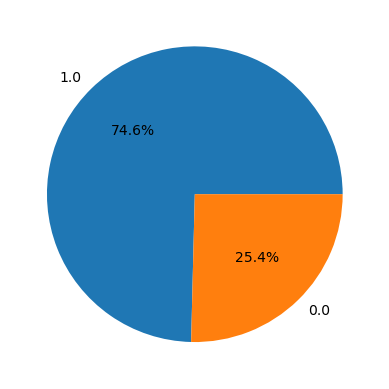

In [12]:
x = df['class'].value_counts()
plt.pie(x.values,
        labels = x.index,
        autopct='%1.1f%%')
plt.show()


Ah! Veri dengesizliği. Aksi takdirde bu veri kümesi üzerinde eğitilen modelin pozitif sınıfları tahmin etmesi daha zor olacak, ki bu da bizim buradaki ana hedefimiz.

### Model Eğitimi

Şimdi özellikleri ve hedef değişkenleri ayırıp bunları eğitim ve test verileri olarak ikiye böleceğiz ve doğrulama verilerinde en iyi performansı gösteren modeli seçeceğiz.

In [14]:
features = df.drop('class', axis=1)
target = df['class']

X_train, X_val,\
    Y_train, Y_val = train_test_split(features, target,
                                    test_size=0.2,
                                    random_state=10)
X_train.shape, X_val.shape

((201, 30), (51, 30))

Azınlık sınıfında aşırı örnekleme yöntemini kullanarak veri dengesizliği sorununu ele almak.

In [15]:
# As the data was highly imbalanced we will balance
# it by adding repetitive rows of minority class.
ros = RandomOverSampler(sampling_strategy='minority',
                        random_state=0)
X, Y = ros.fit_resample(X_train, Y_train)
X.shape, Y.shape


((302, 30), (302,))

Veri temizleme adımında veri seti zaten normalize edilmiş olduğundan, en son teknoloji makine öğrenimi modellerini doğrudan eğitebilir ve verilerimizle hangisinin daha iyi uyduğunu karşılaştırabiliriz.

In [35]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score as ras

models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf', probability=True)]

for model in models:
    model.fit(X, Y)
    print(f'{model.__class__.__name__} : ')
    
    # Training predictions and ROC AUC score
    if hasattr(model, 'predict_proba'):
        train_preds = model.predict_proba(X)[:, 1]
    else:
        train_preds = model.decision_function(X)
    print('Training ROC AUC Score: ', ras(Y, train_preds))
    
    # Validation predictions and ROC AUC score
    if hasattr(model, 'predict_proba'):
        val_preds = model.predict_proba(X_val)[:, 1]
    else:
        val_preds = model.decision_function(X_val)
    print('Validation ROC AUC Score: ', ras(Y_val, val_preds))
    print()


LogisticRegression : 
Training ROC AUC Score:  0.8293495899302662
Validation ROC AUC Score:  0.7907407407407407

XGBClassifier : 
Training ROC AUC Score:  1.0
Validation ROC AUC Score:  0.9981481481481481

SVC : 
Training ROC AUC Score:  0.7104951537213281
Validation ROC AUC Score:  0.6462962962962964



### Model Değerlendirmesi

Yukarıdaki doğruluklardan, Lojistik Regresyon ve SVC() sınıflandırıcısının doğrulama verileri üzerinde, doğrulama ve eğitim verileri arasındaki farkın daha az olduğu daha iyi performans gösterdiğini söyleyebiliriz . Lojistik Regresyon modelini kullanarak doğrulama verileri için de karışıklık matrisini çizelim .

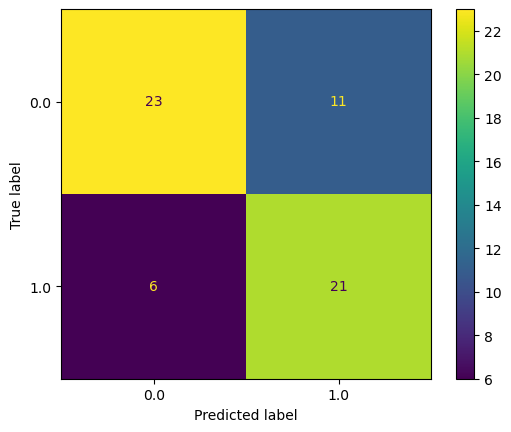

In [30]:
metrics.plot_confusion_matrix(models[0],
                            X_val, Y_val)
plt.show()


In [31]:
print(metrics.classification_report
    (Y_val, models[0].predict(X_val)))


              precision    recall  f1-score   support

         0.0       0.79      0.68      0.73        34
         1.0       0.66      0.78      0.71        27

    accuracy                           0.72        61
   macro avg       0.72      0.73      0.72        61
weighted avg       0.73      0.72      0.72        61



Çözüm:
Oluşturduğumuz makine öğrenme modeli yaklaşık %75 ila %80 oranında doğrudur. Tanı yöntemleri olmayan hastalıklar için makine öğrenme modelleri, kişinin Parkinson hastalığına sahip olup olmadığını tahmin edebilir. Bu, gerçek dünyadaki birçok sorunun çözüldüğü makine öğrenmesinin gücüdür.